Made to inspect models that have been trained.

## Libraries

In [2]:
from pathlib import Path
import sys

ROOT_DIR = Path.cwd()
while not (ROOT_DIR / "models").exists():
    ROOT_DIR = ROOT_DIR.parent
sys.path.insert(0, str(ROOT_DIR))

import csv
import matplotlib.pyplot as plt
import torch
import numpy as np
from pathlib import Path
from training.dataset import BRICKDataset
from models.brick import BRICK
import pandas as pd

## Functions

In [3]:
# ================================================================================
# FUNCTIONS
# ================================================================================

def list_runs(results_root: Path, subfolder: str = None) -> list:
    """List all runs in results/training or a named subfolder."""
    search_root = results_root / subfolder if subfolder else results_root
    csv_files = sorted(search_root.glob("*/loss_history.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No loss_history.csv found in {search_root}")
    print(f"Available runs in '{subfolder or 'root'}':")
    for i, f in enumerate(csv_files):
        print(f"  [{i+1}] {f.parent.name}")
    return csv_files


def load_csv(csv_path: Path) -> dict:
    """Load loss history CSV into lists."""
    data = {k: [] for k in [
        "epochs",
        "train_total", "val_total",
        "train_recon", "val_recon",
        "train_kl_g0", "val_kl_g0",
        "train_kl_u",  "val_kl_u",
        "train_cls",   "val_cls",
    ]}
    with open(csv_path) as f:
        for row in csv.DictReader(f):
            data["epochs"].append(int(row["epoch"]))
            data["train_total"].append(float(row["train_loss_total"]))
            data["val_total"].append(float(row["val_loss_total"]))
            data["train_recon"].append(float(row["train_loss_recon"]))
            data["val_recon"].append(float(row["val_loss_recon"]))
            data["train_kl_g0"].append(float(row["train_loss_kl_g0"]))
            data["val_kl_g0"].append(float(row["val_loss_kl_g0"]))
            data["train_kl_u"].append(float(row["train_loss_kl_u"]))
            data["val_kl_u"].append(float(row["val_loss_kl_u"]))
            data["train_cls"].append(float(row["train_loss_cls"]))
            data["val_cls"].append(float(row["val_loss_cls"]))
    return data


def load_best_epoch(csv_path: Path) -> int | None:
    """Load the best epoch from the checkpoint in the same directory."""
    checkpoint_path = csv_path.parent / "best_model.pt"
    if checkpoint_path.exists():
        checkpoint = torch.load(checkpoint_path, map_location="cpu")
        best_epoch = checkpoint["epoch"]
        print(f"Best model saved at epoch {best_epoch}")
        return best_epoch
    print("No best_model.pt found.")
    return None


def plot_curves(data: dict, best_epoch: int | None, run_name: str, out_path: Path):
    """Plot all loss curves and save to file."""
    epochs = data["epochs"]

    def plot(ax, title, train, val=None):
        ax.plot(epochs, train, label="train", linewidth=1.5)
        if val is not None:
            ax.plot(epochs, val, label="val", linewidth=1.5, linestyle="--")
        if best_epoch is not None:
            ax.axvline(x=best_epoch, color='red', linestyle=':', linewidth=1.5,
                       label=f"best (ep {best_epoch})")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(alpha=0.3)

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(f"BRICK Training Loss Curves\n{run_name}", fontsize=13)

    plot(axes[0, 0], "Total Loss",          data["train_total"],  data["val_total"])
    plot(axes[0, 1], "Reconstruction Loss", data["train_recon"],  data["val_recon"])
    plot(axes[0, 2], "KL g0",               data["train_kl_g0"],  data["val_kl_g0"])
    plot(axes[1, 0], "KL u",                data["train_kl_u"],   data["val_kl_u"])
    plot(axes[1, 1], "Classification Loss", data["train_cls"],    data["val_cls"])
    axes[1, 2].axis("off")

    plt.tight_layout()
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved to {out_path}")
    plt.show()


def plot_ablation(results_root: Path, subfolder: str, out_path: Path):
    """Plot all runs in a subfolder overlaid on the same axes."""
    csv_files = list_runs(results_root, subfolder=subfolder)

    fig, axes = plt.subplots(5, 2, figsize=(14, 20))
    fig.suptitle(f"BRICK Ablation Comparison\n{subfolder}", fontsize=13)

    def plot(ax_train, ax_val, title, key_train, key_val):
        for csv_path in csv_files:
            data = load_csv(csv_path)
            label = csv_path.parent.name
            ax_train.plot(data["epochs"], data[key_train], label=label, linewidth=1.2)
            ax_val.plot(data["epochs"],   data[key_val],   label=label, linewidth=1.2)
        ax_train.set_title(f"{title} — train")
        ax_val.set_title(f"{title} — val")
        for ax in (ax_train, ax_val):
            ax.set_xlabel("Epoch")
            ax.legend(fontsize=7)
            ax.grid(alpha=0.3)

    plot(axes[0, 0], axes[0, 1], "Total Loss",          "train_total",  "val_total")
    plot(axes[1, 0], axes[1, 1], "Reconstruction Loss", "train_recon",  "val_recon")
    plot(axes[2, 0], axes[2, 1], "KL g0",               "train_kl_g0",  "val_kl_g0")
    plot(axes[3, 0], axes[3, 1], "KL u",                "train_kl_u",   "val_kl_u")
    plot(axes[4, 0], axes[4, 1], "Classification Loss", "train_cls",    "val_cls")

    plt.tight_layout()
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved to {out_path}")
    plt.show()

## PLOT

Available runs in 'Test_beta':
  [1] ablation_no_ic_BETA=0
  [2] ablation_no_ic_BETA=0.1

Plotting: ablation_no_ic_BETA=0.1
Best model saved at epoch 2969
Saved to /home/nadegeo/LIFUS-BRICK/results/figures/training_curves_ablation_no_ic_BETA=0.1.png


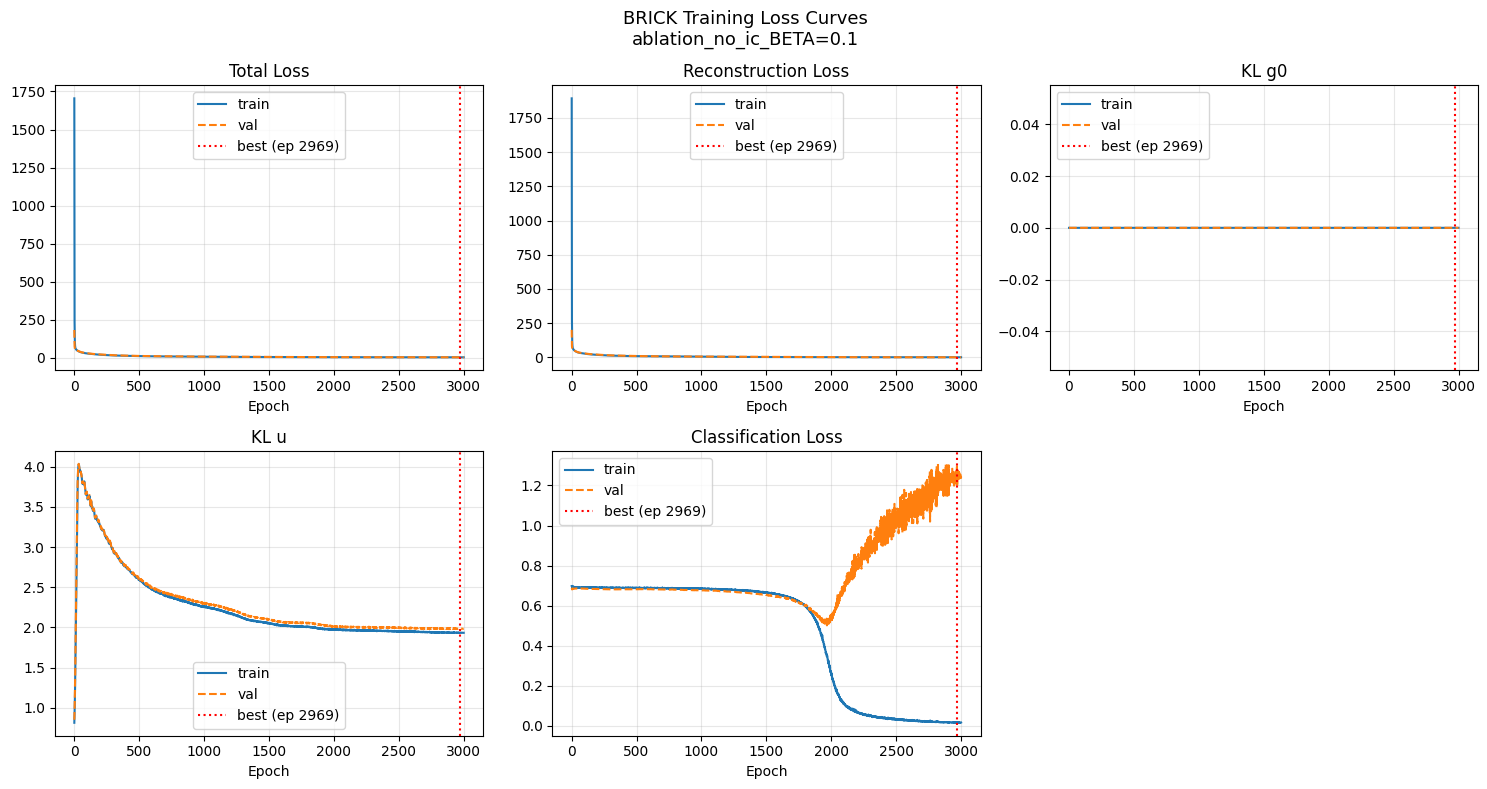

In [7]:
TRAIN_NUMBER = 0  # <-- change this
SUBFOLDER = "Test_beta"  # e.g. "sweep_1", "ablation_BETA=0", or None for root

results_root = ROOT_DIR / "results" / "training"

csv_files  = list_runs(results_root, subfolder=SUBFOLDER)
csv_path   = csv_files[TRAIN_NUMBER - 1]
print(f"\nPlotting: {csv_path.parent.name}")

data       = load_csv(csv_path)
best_epoch = load_best_epoch(csv_path)
out_path   = ROOT_DIR / "results" / "figures" / f"training_curves_{csv_path.parent.name}.png"

plot_curves(data, best_epoch, csv_path.parent.name, out_path)

Available runs in 'Test_beta':
  [1] ablation_no_ic_BETA=0
  [2] ablation_no_ic_BETA=0.1
Best model saved at epoch 3395
Best model saved at epoch 2969
Best model saved at epoch 3395
Best model saved at epoch 2969
Best model saved at epoch 3395
Best model saved at epoch 2969
Best model saved at epoch 3395
Best model saved at epoch 2969
Best model saved at epoch 3395
Best model saved at epoch 2969


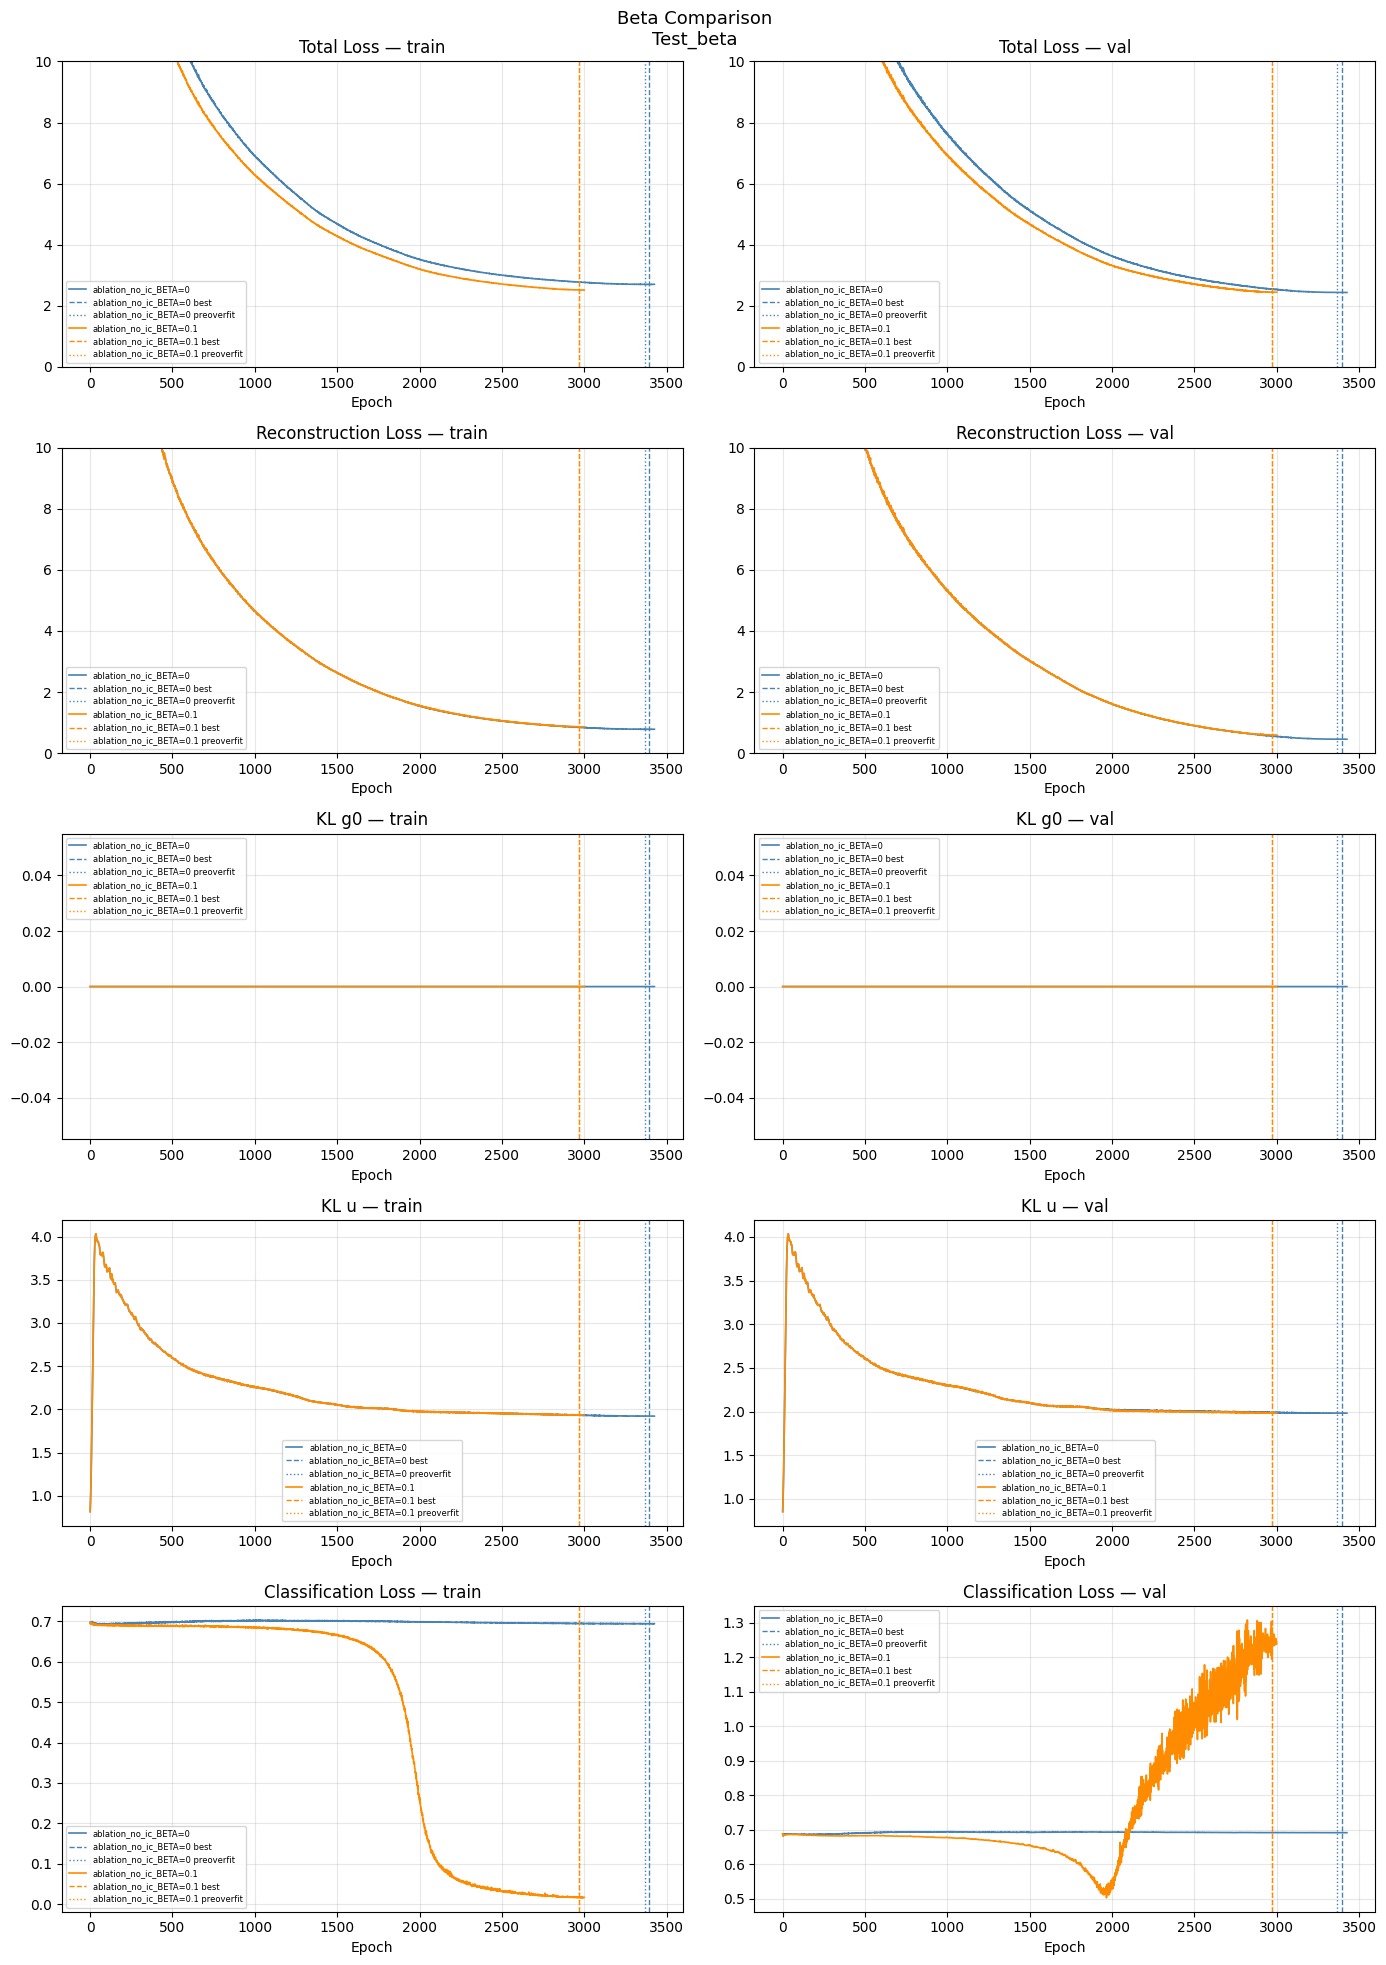


Run                            Checkpoint      Best Val Recon     Best Val Cls    Epoch   
------------------------------------------------------------------------------------------
Best model saved at epoch 3395
ablation_no_ic_BETA=0          best            0.4567             0.6911          3395    
ablation_no_ic_BETA=0          preoverfit      0.4585             0.6911          3366    

Best model saved at epoch 2969
ablation_no_ic_BETA=0.1        best            0.5973             1.1947          2969    
ablation_no_ic_BETA=0.1        preoverfit      0.5973             1.1947          2969    



In [5]:
#DO WE USE BETA

def plot_beta_comparison(results_root: Path, subfolder: str):
    """
    Plot both runs in subfolder, each with both best and preoverfit checkpoints marked.
    Also prints a comparison table.
    """
    csv_files = list_runs(results_root, subfolder=subfolder)

    fig, axes = plt.subplots(5, 2, figsize=(14, 20))
    fig.suptitle(f"Beta Comparison\n{subfolder}", fontsize=13)

    colors = {"ablation_no_ic_BETA=0": "steelblue", "ablation_no_ic_BETA=0.1": "darkorange"}

    def plot(ax_train, ax_val, title, key_train, key_val, ylim=None):

        if ylim is not None:
            ax_train.set_ylim(ylim)
            ax_val.set_ylim(ylim)
        
        for csv_path in csv_files:
            data      = load_csv(csv_path)
            run_name  = csv_path.parent.name
            color     = colors.get(run_name, "gray")

            ax_train.plot(data["epochs"], data[key_train], label=run_name, color=color, linewidth=1.2)
            ax_val.plot(data["epochs"],   data[key_val],   label=run_name, color=color, linewidth=1.2)

            # Mark best_model.pt epoch
            best_epoch = load_best_epoch(csv_path)
            if best_epoch:
                for ax, key in [(ax_train, key_train), (ax_val, key_val)]:
                    ax.axvline(x=best_epoch, color=color, linestyle="--", linewidth=1.0,
                               label=f"{run_name} best")

            # Mark best_model_preoverfit.pt epoch
            preoverfit_path = csv_path.parent / "best_model_preoverfit.pt"
            if preoverfit_path.exists():
                ckpt = torch.load(preoverfit_path, map_location="cpu")
                pre_epoch = ckpt["epoch"]
                for ax in (ax_train, ax_val):
                    ax.axvline(x=pre_epoch, color=color, linestyle=":", linewidth=1.0,
                               label=f"{run_name} preoverfit")

        ax_train.set_title(f"{title} — train")
        ax_val.set_title(f"{title} — val")
        for ax in (ax_train, ax_val):
            ax.set_xlabel("Epoch")
            ax.legend(fontsize=6)
            ax.grid(alpha=0.3)

    plot(axes[0, 0], axes[0, 1], "Total Loss",          "train_total",  "val_total",  ylim=(0, 10))
    plot(axes[1, 0], axes[1, 1], "Reconstruction Loss", "train_recon",  "val_recon",  ylim=(0, 10))
    plot(axes[2, 0], axes[2, 1], "KL g0",               "train_kl_g0",  "val_kl_g0")
    plot(axes[3, 0], axes[3, 1], "KL u",                "train_kl_u",   "val_kl_u")
    plot(axes[4, 0], axes[4, 1], "Classification Loss", "train_cls",    "val_cls")

    plt.tight_layout()
    plt.show()

    # --- Comparison table ---
    print(f"\n{'Run':<30} {'Checkpoint':<15} {'Best Val Recon':<18} {'Best Val Cls':<15} {'Epoch':<8}")
    print("-" * 90)
    for csv_path in csv_files:
        df = pd.read_csv(csv_path)
        run_name = csv_path.parent.name

        # best_model.pt
        best_epoch = load_best_epoch(csv_path)
        if best_epoch:
            row = df[df["epoch"] == best_epoch].iloc[0]
            print(f"{run_name:<30} {'best':<15} {float(row['val_loss_recon']):<18.4f} "
                  f"{float(row['val_loss_cls']):<15.4f} {best_epoch:<8}")

        # best_model_preoverfit.pt
        preoverfit_path = csv_path.parent / "best_model_preoverfit.pt"
        if preoverfit_path.exists():
            ckpt = torch.load(preoverfit_path, map_location="cpu")
            pre_epoch = ckpt["epoch"]
            row = df[df["epoch"] == pre_epoch].iloc[0]
            print(f"{run_name:<30} {'preoverfit':<15} {float(row['val_loss_recon']):<18.4f} "
                  f"{float(row['val_loss_cls']):<15.4f} {pre_epoch:<8}")
        print()

plot_beta_comparison(
    results_root=ROOT_DIR / "results" / "training",
    subfolder="Test_beta",
)

Plot Ablation

Available runs in 'ablation_BETA=0':
  [1] ablation_full
  [2] ablation_no_control
  [3] ablation_no_control_no_ic
  [4] ablation_no_ic

Plotting: ablation_full
Best model saved at epoch 1399
Available runs in 'ablation_BETA=0':
  [1] ablation_full
  [2] ablation_no_control
  [3] ablation_no_control_no_ic
  [4] ablation_no_ic
Saved to c:\Users\USER\Documents\GitHub\LIFUS-BRICK\results\figures\comparison_ablation_BETA=0.png


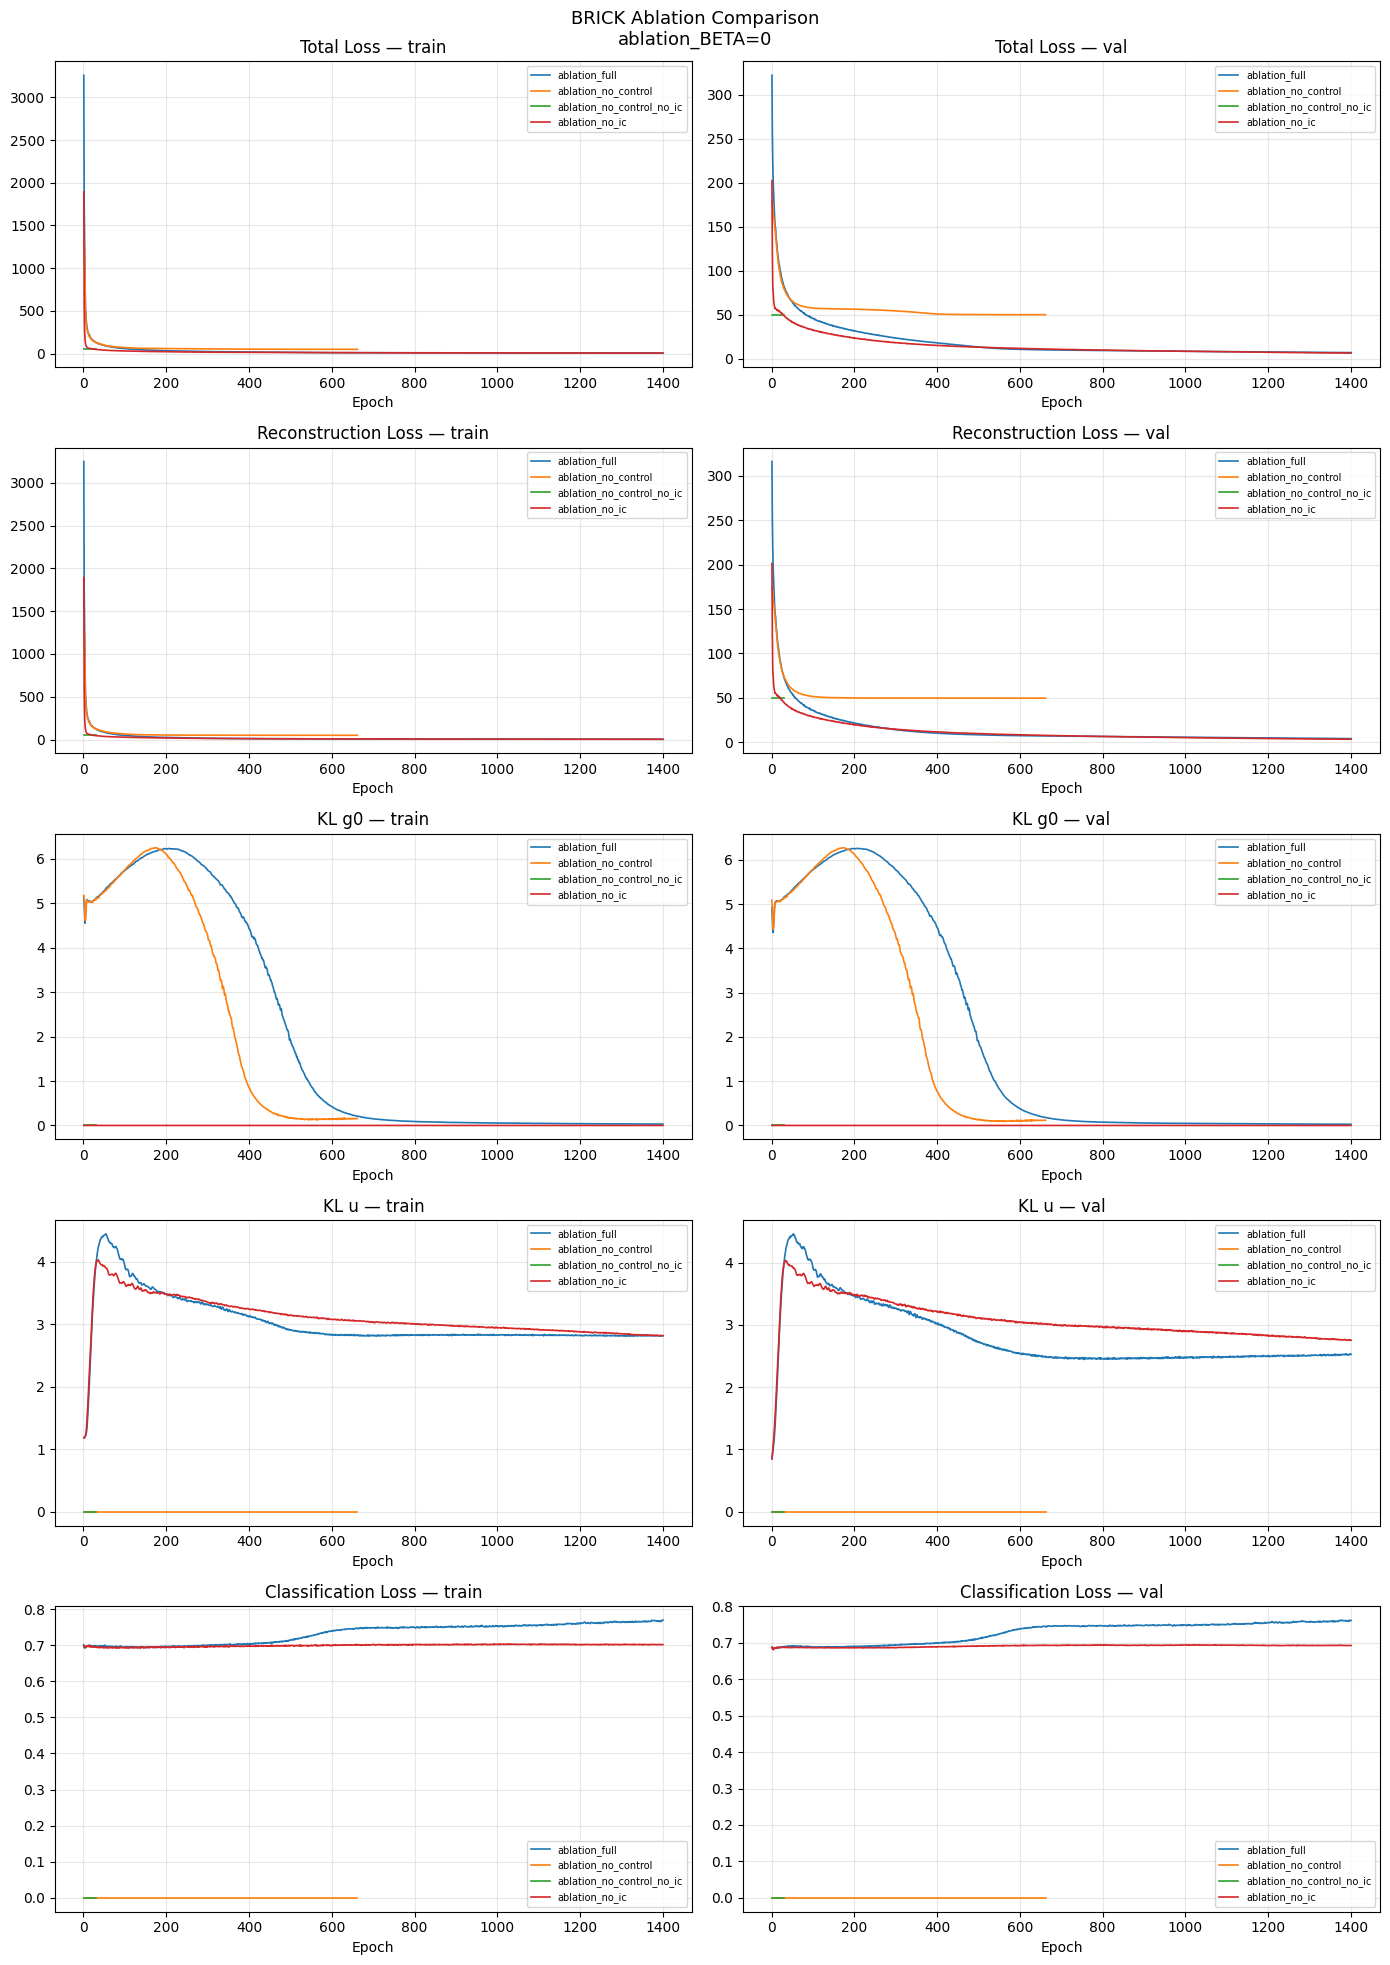

In [14]:
TRAIN_NUMBER = 1  # <-- change this
SUBFOLDER = "ablation_BETA=0"  # e.g. "sweep_1", "ablation_BETA=0", or None for root

results_root = ROOT_DIR / "results" / "training"

csv_files  = list_runs(results_root, subfolder=SUBFOLDER)
csv_path   = csv_files[TRAIN_NUMBER - 1]
print(f"\nPlotting: {csv_path.parent.name}")

data       = load_csv(csv_path)
best_epoch = load_best_epoch(csv_path)
out_path   = ROOT_DIR / "results" / "figures" / f"training_curves_{csv_path.parent.name}.png"

plot_ablation(
    results_root=ROOT_DIR / "results" / "training",
    subfolder="ablation_BETA=0",
    out_path=ROOT_DIR / "results" / "figures" / "comparison_ablation_BETA=0.png"
)

### Test Load Model

In [ ]:
import torch
from models.brick import BRICK

checkpoint = torch.load("results/training/your_run_name/best_model.pt")

model = BRICK(
    use_control=checkpoint["use_control"],
    use_ic=checkpoint["use_ic"],
    h=checkpoint["h"],
    m=checkpoint["m"],
)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

### Test for VAE posterior collapse vs code bug (grdients not flowing properly)

In [7]:
import torch
from training.dataset import BRICKDataset
from models.brick import BRICK
from pathlib import Path

ds = BRICKDataset(Path("data/preprocessed_data"))

checkpoint = torch.load("results/training/train_20260619_134312/best_model.pt", map_location="cpu")
model = BRICK(use_control=True, use_ic=True, h=2, nhead=2)
model.load_state_dict(checkpoint["model_state_dict"])
model.train()

x     = ds[0]["x"]
label = ds[0]["lifus_condition"]
out   = model(x, label)
out["losses"]["loss_total"].backward()

print("Encoder gradients:")
for name, param in model.encoder.named_parameters():
    if param.grad is not None:
        print(f"  {name}: grad_norm={param.grad.norm().item():.6f}")
    else:
        print(f"  {name}: NO GRADIENT")

Encoder gradients:
  row_mlp.0.weight: grad_norm=0.000000
  row_mlp.0.bias: grad_norm=0.000000
  row_mlp.2.weight: grad_norm=0.000000
  row_mlp.2.bias: grad_norm=0.000000
  mu_head.layers.0.self_attn.in_proj_weight: grad_norm=0.000000
  mu_head.layers.0.self_attn.in_proj_bias: grad_norm=0.000000
  mu_head.layers.0.self_attn.out_proj.weight: grad_norm=0.000000
  mu_head.layers.0.self_attn.out_proj.bias: grad_norm=0.000000
  mu_head.layers.0.linear1.weight: grad_norm=0.000000
  mu_head.layers.0.linear1.bias: grad_norm=0.000000
  mu_head.layers.0.linear2.weight: grad_norm=0.000000
  mu_head.layers.0.linear2.bias: grad_norm=0.000000
  mu_head.layers.0.norm1.weight: grad_norm=0.000000
  mu_head.layers.0.norm1.bias: grad_norm=0.000000
  mu_head.layers.0.norm2.weight: grad_norm=0.000083
  mu_head.layers.0.norm2.bias: grad_norm=0.000083
  mu_head.layers.1.self_attn.in_proj_weight: grad_norm=0.000056
  mu_head.layers.1.self_attn.in_proj_bias: grad_norm=0.000040
  mu_head.layers.1.self_attn.out_

This is vanishing gradients in the early layers — a secondary issue on top of posterior collapse. The first row_mlp and first transformer layer are essentially not learning because gradients diminish as they backpropagate through the network.
This is expected behavior for a collapsed VAE — when mu≈0 and sigma≈1 (prior), the KL gradient is near zero, so very little signal flows back through the encoder. It's a consequence of collapse, not an independent bug.
Conclusion: No code bug. The collapse is genuine VAE behavior caused by the loss landscape. KL annealing is the right fix — it forces reconstruction gradients to flow through the encoder before KL pressure can cause collapse, which would give the early layers a chance to learn.